In [24]:
from ml.dataset import get_dataloaders
from ml.models import Conv1Layer, Conv2Layer, Conv3Layer, Conv4Layer, Conv5Layer
from ml.visualization import plot_results, summarize_results, compare_models
from ml.train import Trainer
from ml.utils import *

%load_ext autoreload
%autoreload 2

import logging
import torch
import torch.optim as optim
from torch import nn
import gc

logger = logging.getLogger("Main")
logging.basicConfig(
    filename="logger.log",
    filemode="w",
    level=logging.INFO,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

train_loader, val_loader, test_loader = get_dataloaders()

In [3]:
def run_experiment(
        model: nn.Module,
        model_name: str,
        lr: float = 0.001,
        max_epochs: int = 20,
        patience: int = 5,
) -> tuple[float, float, Trainer]:

    loss_fn  = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=2)

    trainer = Trainer(
        model = model,
        model_name = model_name,
        loss_fn = loss_fn,
        optimizer = optimizer,
        train_loader = train_loader,
        val_loader = val_loader,
        device = device,
        logger=logger,
        scheduler = scheduler,
    )

    val_loss, val_acc = trainer.train_and_validate(max_epochs = max_epochs, patience = patience)

    return val_loss, val_acc, trainer

In [4]:
def run_experiments(exps: list[Experiment], visualize = False):
    for exp in exps:
        model = exp.model_cls(**exp.kwargs)

        val_loss, val_acc, trainer = run_experiment(model = model, model_name = exp.model_name)
        print(f"{exp.model_name}: validation loss: {val_loss:.4f}, validation accuracy: {val_acc:.4f}")

        if visualize:
            plot_results(progress = trainer.progress, model_name = exp.model_name)
        exp.progress = trainer.progress

        del model
        del trainer
        gc.collect()
        if torch.mps.is_available():
            torch.mps.empty_cache()


In [5]:
try:
    all_experiments = load_experiments()
except FileNotFoundError:
    all_experiments = []
except json.JSONDecodeError:
    all_experiments = []

11 Experiments loaded from experiments.json successfully


Conv1_32: validation loss: 2.3080, validation accuracy: 0.5723


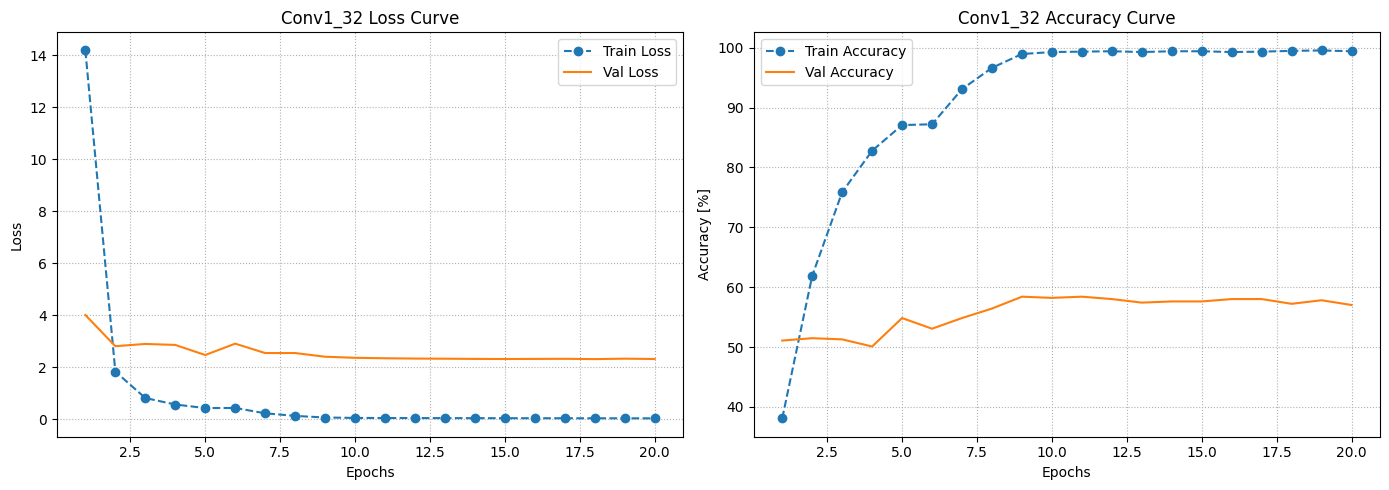

Conv1_64: validation loss: 3.1232, validation accuracy: 0.5723


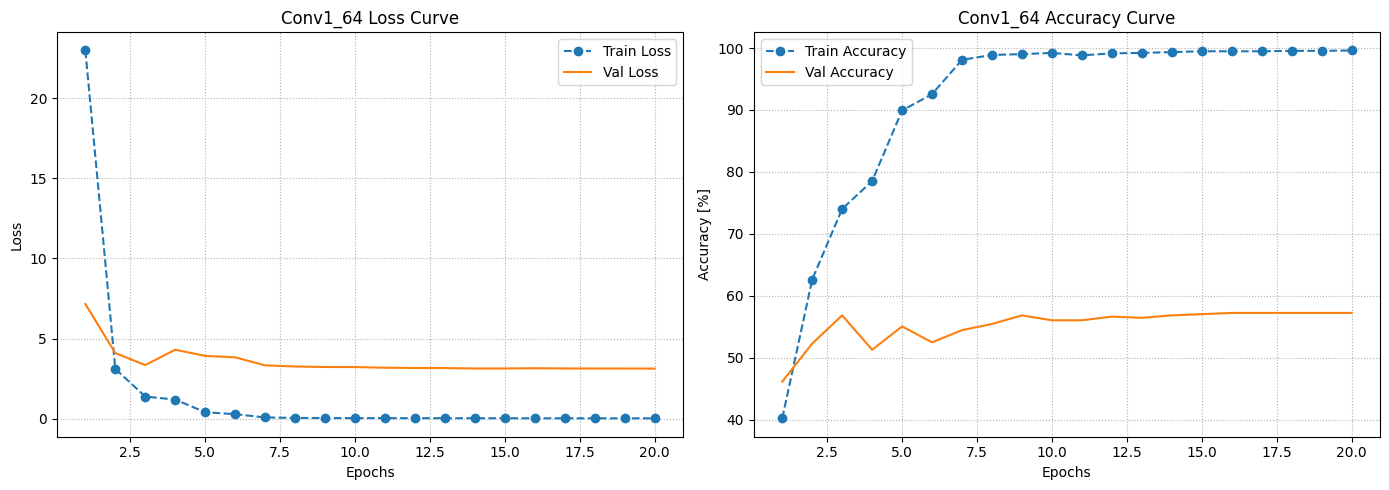

2 Experiments saved to experiments.json successfully


In [6]:
experiments = [
    Experiment("Conv1_32", Conv1Layer, {"n1" : 32}),
    Experiment("Conv1_64", Conv1Layer, {"n1" : 64}),
]

run_experiments(experiments, True)
all_experiments.extend(experiments)
save_experiments(all_experiments)

In [7]:
experiments2 = [
    Experiment("Conv2_16_32", Conv2Layer, {"n1" : 16, "n2" : 32}),
    Experiment("Conv2_32_64", Conv2Layer, {"n1" : 32, "n2" : 64}),
    Experiment("Conv2_32_32", Conv2Layer, {"n1" : 32, "n2" : 32}),
]
run_experiments(experiments2, False)
all_experiments.extend(experiments2)
save_experiments(all_experiments)

Conv2_16_32: validation loss: 1.2030, validation accuracy: 0.5802
Conv2_32_64: validation loss: 1.2903, validation accuracy: 0.5465
Conv2_32_32: validation loss: 1.2531, validation accuracy: 0.5604
5 Experiments saved to experiments.json successfully


In [8]:
experiments3 = [
    Experiment("Conv3_16_32_64", Conv3Layer, {"n1" : 16, "n2" : 32,"n3" : 64}),
    Experiment("Conv3_32_64_128", Conv3Layer, {"n1" : 32, "n2" : 64, "n3" : 128}),
]
run_experiments(experiments3, False)
all_experiments.extend(experiments3)
save_experiments(all_experiments)

Conv3_16_32_64: validation loss: 1.1056, validation accuracy: 0.5960
Conv3_32_64_128: validation loss: 1.1035, validation accuracy: 0.6337
7 Experiments saved to experiments.json successfully


In [9]:
experiments4 = [
    Experiment("Conv4_16_32_64_128", Conv4Layer, {"n1" : 16,"n2" : 32,"n3" : 64, "n4" : 128}),
    Experiment("Conv4_32_64_128_256", Conv4Layer, {"n1" : 32,"n2" : 64, "n3" : 128, "n4" : 256}),
]
run_experiments(experiments4, False)
all_experiments.extend(experiments4)
save_experiments(all_experiments)

Conv4_16_32_64_128: validation loss: 1.1137, validation accuracy: 0.6139
Conv4_32_64_128_256: validation loss: 0.9973, validation accuracy: 0.6297
9 Experiments saved to experiments.json successfully


In [10]:
experiments5 = [
    Experiment("Conv5_16_32_64_128_256", Conv5Layer, {"n1" : 16,"n2" : 32,"n3" : 64, "n4" : 128,"n5" : 256}),
    Experiment("Conv5_32_64_128_256_512", Conv5Layer, {"n1" : 32, "n2" : 64, "n3" : 128, "n4" : 256, "n5" : 512}),
]
run_experiments(experiments5, False)
all_experiments.extend(experiments5)
save_experiments(all_experiments)

Conv5_16_32_64_128_256: validation loss: 1.0933, validation accuracy: 0.6277
Conv5_32_64_128_256_512: validation loss: 1.0797, validation accuracy: 0.6554
11 Experiments saved to experiments.json successfully


In [23]:
summary = summarize_results(all_experiments)
display(summary)

,Model,Best Val Acc [%],Min Val Loss,Final Train Loss,Final Train Acc [%],Epochs
8,Conv4_32_64_128_256,67.33,0.9973,0.1621,96.04,10
9,Conv5_16_32_64_128_256,65.94,1.0933,0.1403,95.98,14
10,Conv5_32_64_128_256_512,65.74,1.0797,0.1209,97.23,13
7,Conv4_16_32_64_128,63.96,1.1137,0.0843,98.42,12
5,Conv3_16_32_64,63.56,1.1056,0.1465,96.64,9
6,Conv3_32_64_128,63.37,1.1035,0.0915,98.02,9
4,Conv2_32_32,60.40,1.2531,0.0936,98.42,9
2,Conv2_16_32,60.00,1.2030,0.1816,96.18,8
0,Conv1_32,58.42,2.3080,0.0290,99.41,20
3,Conv2_32_64,58.22,1.2903,0.1144,97.56,9


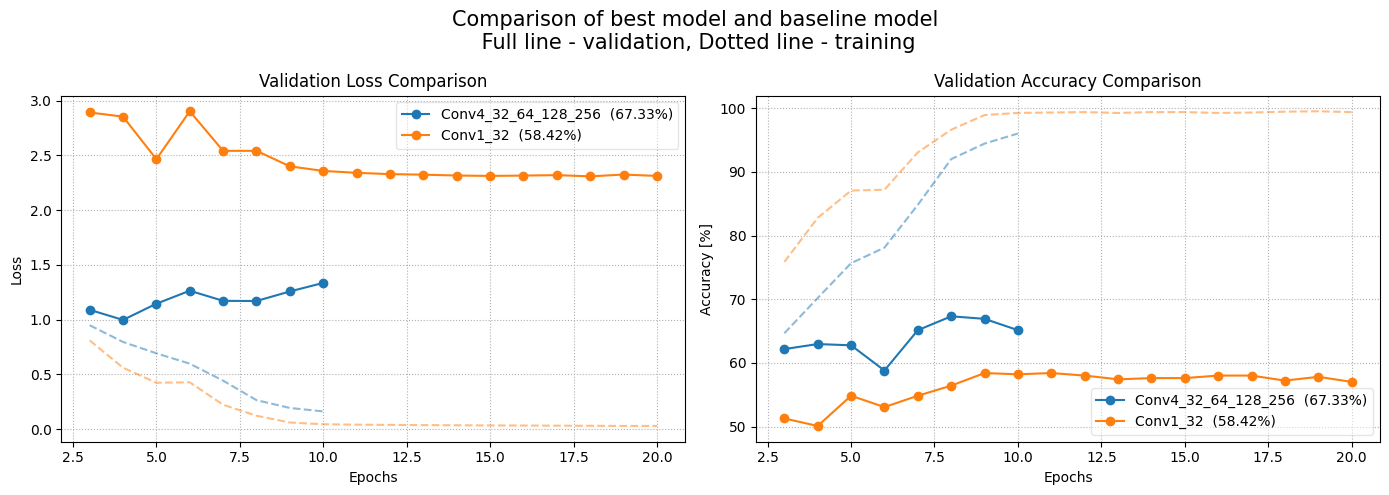

In [66]:
experiments = []
experiments.append(min(all_experiments, key=lambda exp: min(r.val_loss for r in exp.progress)))
experiments.append(all_experiments[0])
compare_models(
    experiments,
    title = "Comparison of best model and baseline model",
    epoch_start=2,
    show_train=True,
)

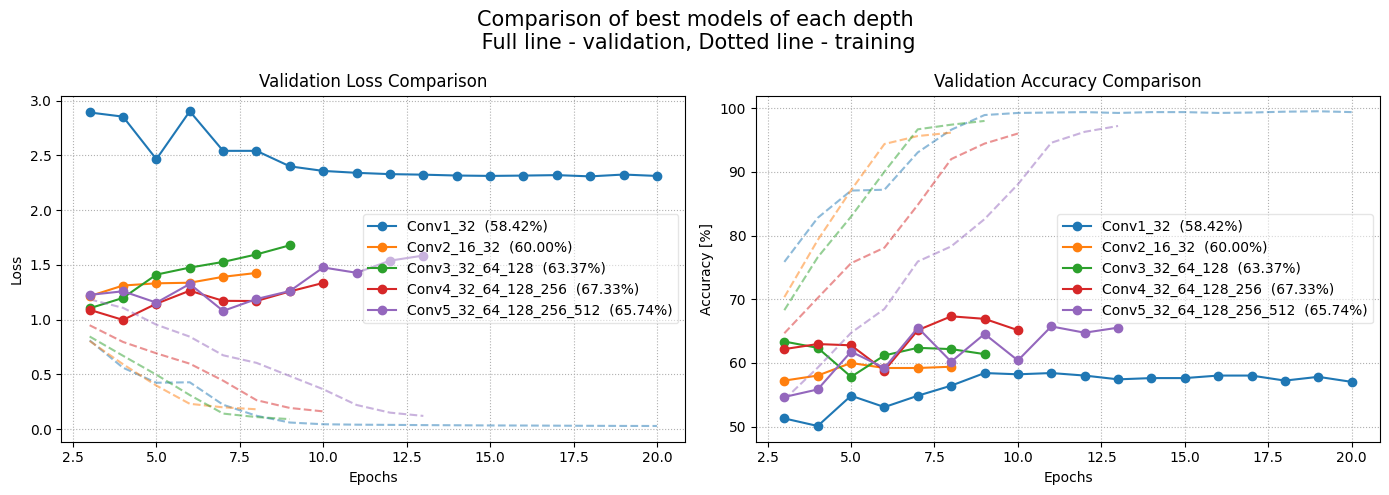

In [64]:
categories = ["Conv1", "Conv2", "Conv3", "Conv4", "Conv5"]
experiments_by_cat: list[list[Experiment]] = []
for cat in categories:
    exps = [e for e in all_experiments if e.model_name.startswith(cat)]
    if exps:
        experiments_by_cat.append(exps)

# gets best model for each category
best_experiments = [min(experiments, key=lambda exp: min(r.val_loss for r in exp.progress)) for experiments in experiments_by_cat]
compare_models(
    best_experiments,
    title = "Comparison of best models of each depth",
    epoch_start=2,
    show_train=True,
)